Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Install & Import Libraries

In [ ]:
!pip install -q albumentations

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from glob import glob

Dataset Loading + 70/15/15 Split

In [ ]:
DATA_DIR = "/content/drive/My Drive/Food Dataset"

fresh_images = glob(os.path.join(DATA_DIR, "Fresh", "*"))
stale_images = glob(os.path.join(DATA_DIR, "Stale", "*"))

images = fresh_images + stale_images
labels = [0]*len(fresh_images) + [1]*len(stale_images)

# 70% Train
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.30, stratify=labels, random_state=42)

# 15% Val / 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

Train: 1400
Val: 300
Test: 300


Reflectance Estimation

In [ ]:
IMG_SIZE = 224

def reflectance_estimation(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Variance map (diffuse indicator)
    mean = cv2.blur(img_gray, (7,7))
    variance = cv2.blur((img_gray - mean)**2, (7,7))

    # Laplacian for surface roughness
    laplacian = cv2.Laplacian(img_gray, cv2.CV_64F)
    laplacian = np.absolute(laplacian)

    reflectance_map = cv2.normalize(variance + laplacian, None, 0, 1, cv2.NORM_MINMAX)

    return reflectance_map

Moisture Sensitivity Map (Pixel-wise Dryness)

In [ ]:
def moisture_sensitivity_map(reflectance_map):
    # High reflectance variance = dryness
    dryness_prob = reflectance_map
    dryness_prob = np.expand_dims(dryness_prob, axis=-1)
    return dryness_prob

Data Generator

In [ ]:
BATCH_SIZE = 16

def preprocess_image(path, label):
    path = path.numpy().decode()

    img = cv2.imread(path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    reflectance = reflectance_estimation(img)
    moisture_map = moisture_sensitivity_map(reflectance)

    img = img.astype(np.float32) / 255.0
    moisture_map = moisture_map.astype(np.float32)

    label = np.array(label, dtype=np.float32)

    return img, moisture_map, label


def tf_preprocess(path, label):
    rgb, ref, lab = tf.py_function(
        preprocess_image,
        [path, label],
        [tf.float32, tf.float32, tf.float32]
    )

    rgb.set_shape((IMG_SIZE, IMG_SIZE, 3))
    ref.set_shape((IMG_SIZE, IMG_SIZE, 1))
    lab.set_shape(())

    return ({"RGB_Input": rgb,
             "Reflectance_Input": ref}, lab)


def create_dataset(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.shuffle(len(paths))
    ds = ds.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

RMS-Net Architecture

In [ ]:
# RGB Stream
rgb_input = layers.Input(shape=(224,224,3), name="RGB_Input")

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_tensor=rgb_input)

# ✅ Allow deeper learning (IMPORTANT)
for layer in base_model.layers[:-80]:
    layer.trainable = False

rgb_features = layers.GlobalAveragePooling2D()(base_model.output)

# Reflectance Stream
ref_input = layers.Input(shape=(224,224,1), name="Reflectance_Input")

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(ref_input)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)

# Merge Dual Streams
merged = layers.Concatenate()([rgb_features, x])
merged = layers.Dense(256, activation='relu')(merged)
merged = layers.Dropout(0.4)(merged)

output = layers.Dense(1, activation='sigmoid')(merged)

model = models.Model(inputs=[rgb_input, ref_input], outputs=output)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_ds = create_dataset(X_train, y_train)
val_ds   = create_dataset(X_val, y_val)
test_ds  = create_dataset(X_test, y_test)

Physics-Aware Loss

In [ ]:
def physics_aware_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

    # Penalize if predicted fresh (0) but reflectance suggests dry
    penalty = tf.where(
        tf.logical_and(tf.equal(y_true, 0), y_pred < 0.5),
        0.2,
        0.0)


    return bce + penalty

Compile Model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=physics_aware_loss,
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ RGB_Input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ RGB_Input[0][0]   │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,412,964 (16.83 MB)

 Trainable params: 3,594,621 (13.71 MB)

 Non-trainable params: 818,343 (3.12 MB)

Train RMS-Net

In [ ]:
callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.3,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        patience=10,          # allow more epochs
        mode="max",
        restore_best_weights=True
    ),
]
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 242s 2s/step - accuracy: 0.5757 - loss: 0.7332 - val_accuracy: 0.5000 - val_loss: 0.7963 - learning_rate: 1.0000e-04
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 260ms/step - accuracy: 0.6021 - loss: 0.6962 - val_accuracy: 0.5000 - val_loss: 0.7927 - learning_rate: 1.0000e-04
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 265ms/step - accuracy: 0.6357 - loss: 0.6813 - val_accuracy: 0.5867 - val_loss: 0.7135 - learning_rate: 1.0000e-04
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 22s 248ms/step - accuracy: 0.6357 - loss: 0.6642 - val_accuracy: 0.5000 - val_loss: 0.7371 - learning_rate: 1.0000e-04
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 261ms/step - accuracy: 0.7050 - loss: 0.6299 - val_accuracy: 0.5033 - val_loss: 0.8465 - learning_rate: 1.0000e-04
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.6669 - loss: 0.6530
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
88/88 ━━━━━━━━━━━━━━━━━━━━ 41s 262ms/step - accuracy: 

Save RMS-Net model

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/RMS_Net_Model.keras"

model.save(MODEL_PATH)

print("✅ Model saved at:", MODEL_PATH)

✅ Model saved at: /content/drive/MyDrive/RMS_Net_Model.keras


Unlock full Efficient

In [ ]:
# Unlock full EfficientNet
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # smaller LR
    loss=physics_aware_loss,
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 95s 624ms/step - accuracy: 0.8007 - loss: 0.5030 - val_accuracy: 0.7800 - val_loss: 0.5198
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 281ms/step - accuracy: 0.7936 - loss: 0.4929 - val_accuracy: 0.8133 - val_loss: 0.4794
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 40s 266ms/step - accuracy: 0.7979 - loss: 0.4827 - val_accuracy: 0.8300 - val_loss: 0.4859
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 258ms/step - accuracy: 0.7879 - loss: 0.5123 - val_accuracy: 0.8133 - val_loss: 0.5332
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 267ms/step - accuracy: 0.7721 - loss: 0.5108 - val_accuracy: 0.8167 - val_loss: 0.4705


Evaluate

In [ ]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc * 100)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - accuracy: 0.8233 - loss: 0.4687
Test Accuracy: 82.33333230018616


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


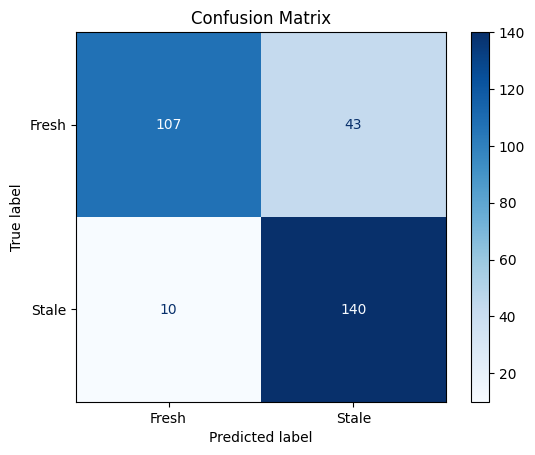

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_true = []
y_pred = []

for batch in test_ds:
    inputs, labels = batch
    preds = model.predict(inputs)

    preds = (preds > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Fresh","Stale"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")

report = classification_report(
    y_true,
    y_pred,
    target_names=["Fresh","Stale"]
)

print(report)


Classification Report:

              precision    recall  f1-score   support

       Fresh       0.91      0.71      0.80       150
       Stale       0.77      0.93      0.84       150

    accuracy                           0.82       300
   macro avg       0.84      0.82      0.82       300
weighted avg       0.84      0.82      0.82       300



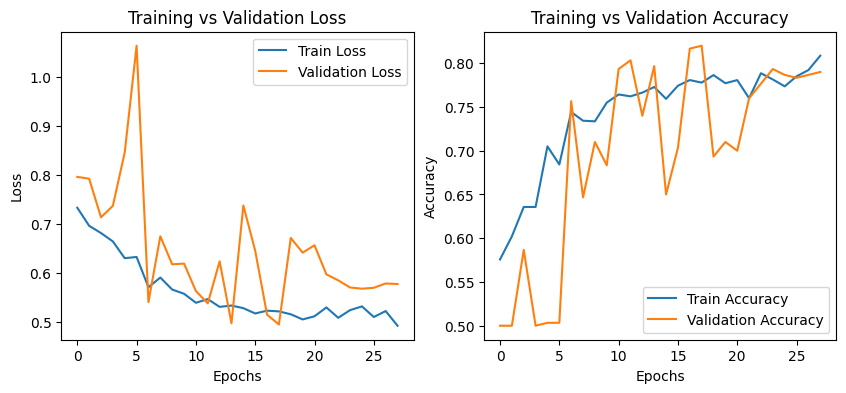

In [ ]:
plt.figure(figsize=(10,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


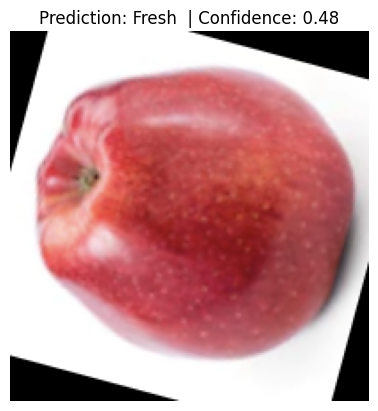

Image path: /content/drive/My Drive/Food Dataset/Fresh/rotated_by_75_Screen Shot 2018-06-08 at 5.09.31 PM.png
Prediction: Fresh
Confidence: 0.48042068


In [ ]:
import random

all_images = fresh_images + stale_images

random_image = random.choice(all_images)

img = cv2.imread(random_image)
img_resized = cv2.resize(img, (224,224))

reflectance = reflectance_estimation(img_resized)
moisture_map = moisture_sensitivity_map(reflectance)

img_input = img_resized.astype(np.float32) / 255.0
ref_input = moisture_map.astype(np.float32)

img_input = np.expand_dims(img_input, axis=0)
ref_input = np.expand_dims(ref_input, axis=0)

prediction = model.predict({
    "RGB_Input": img_input,
    "Reflectance_Input": ref_input
})

pred_label = "Fresh" if prediction[0][0] < 0.5 else "Stale"
confidence = prediction[0][0]

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Prediction: {pred_label}  | Confidence: {confidence:.2f}")
plt.axis("off")
plt.show()

print("Image path:", random_image)
print("Prediction:", pred_label)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


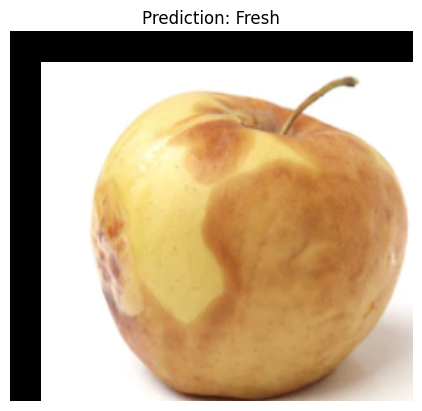

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


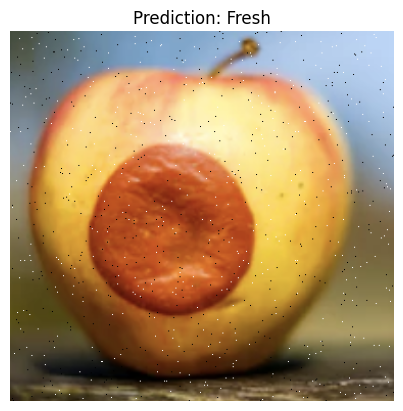

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


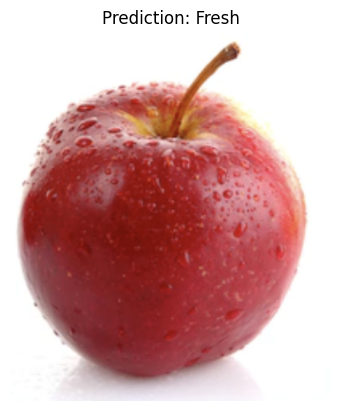

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


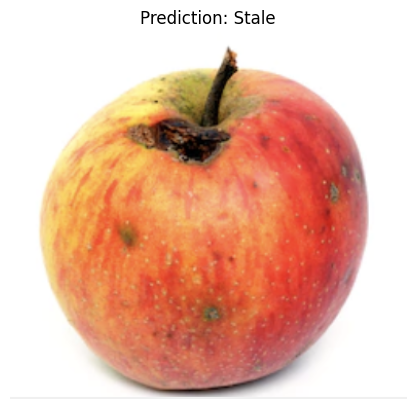

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


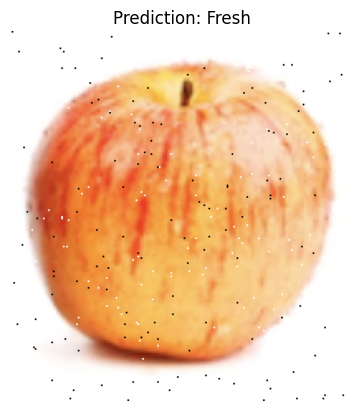

In [ ]:
for i in range(5):

    random_image = random.choice(all_images)

    img = cv2.imread(random_image)
    img_resized = cv2.resize(img,(224,224))

    reflectance = reflectance_estimation(img_resized)
    moisture_map = moisture_sensitivity_map(reflectance)

    img_input = img_resized.astype(np.float32)/255.0
    ref_input = moisture_map.astype(np.float32)

    img_input = np.expand_dims(img_input,axis=0)
    ref_input = np.expand_dims(ref_input,axis=0)

    prediction = model.predict({
        "RGB_Input":img_input,
        "Reflectance_Input":ref_input
    })

    pred_label = "Fresh" if prediction[0][0] < 0.5 else "Stale"

    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {pred_label}")
    plt.axis("off")
    plt.show()